In [1]:
from frap_utils import *

## Generate list of paths

In [2]:
# Create list of paths to the final files
sample_names = ["WT", "100uM_As_2h"]

# Path to main folder
root_folder = Path("/mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP")

# Path to the folder to save final graphs
graphs_folder = check_dir_exists(root_folder / "final_graphs_new")

list_of_paths = []
for sample in sample_names:
    filepath = check_file_exists(root_folder / sample / "EasyFRAP_new" / f"easyFRAP_Final_Data_{sample}_MFI_filtrated.csv")
    list_of_paths.append(filepath)
    print(f"File: {filepath}")

print(f"There are {len(list_of_paths)} files founded.")

Directory /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new is created.
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/WT/EasyFRAP_new/easyFRAP_Final_Data_WT_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/100uM_As_2h/EasyFRAP_new/easyFRAP_Final_Data_100uM_As_2h_MFI_filtrated.csv
There are 2 files founded.


## Import data

In [3]:
# Import data
dfs = []  # list of DataFrames

for p in list_of_paths:
    df = pd.read_csv(p, header=0)
    dfs.append(df)

print(f"Loaded {len(dfs)} files.")

Loaded 2 files.


## Histograms of nuclei MFI

Plot for WT is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new.


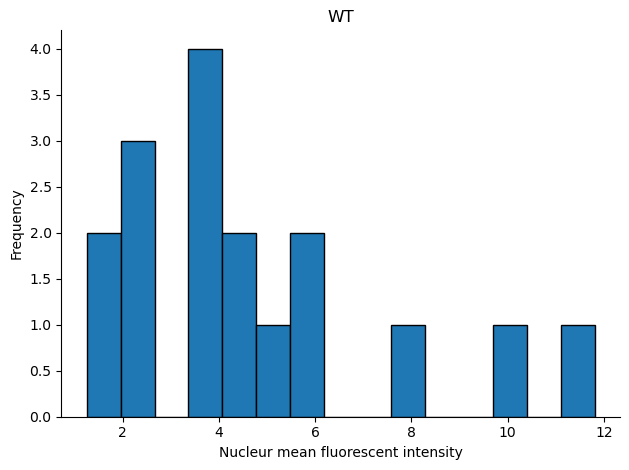

Plot for 100uM_As_2h is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new.


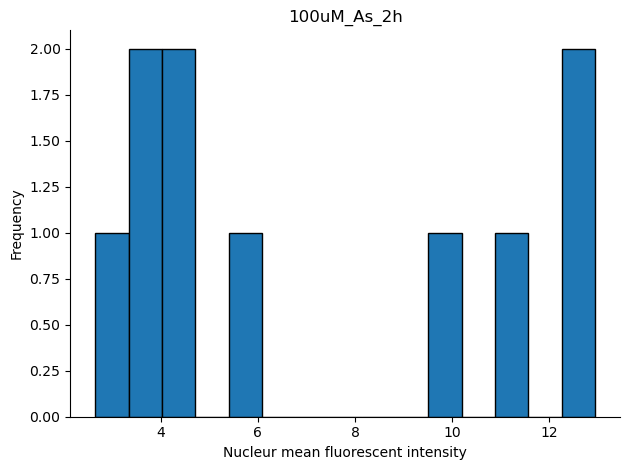

In [4]:
# Histograms of Nuclear MFI
for i, sample_name in zip(range(len(dfs)), sample_names):

    var = dfs[i]["mean_intensity"]
    plt.hist(var, bins = 15, edgecolor='black')
    plt.xlabel("Nucleur mean fluorescent intensity")
    plt.ylabel("Frequency")
    plt.title(sample_names[i])

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # Save image
    plt.savefig(graphs_folder/f"Nuclei_MFI_hist_{sample_name}.png", dpi=300, bbox_inches="tight")
    print(f"Plot for {sample_name} is saved in the directory: {graphs_folder}.")

    plt.show()

## *Optional: delete outliers*

In [ ]:
dfs[3]

In [ ]:
dfs[3] = dfs[3].drop(index=10)

## *Optional: extra filtration based on the nuclei MFI*

In [ ]:
threshold_MFI = 16
dfs_filtered = []
for i in range(len(dfs)):
    df_filtered = dfs[i][dfs[i]['mean_intensity'] < threshold_MFI]
    dfs_filtered.append(df_filtered)
    print(f"{i}: keep {len(df_filtered)} out of {len(dfs[i])} rows.")

## Boxplots

Plot T-half for is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new.


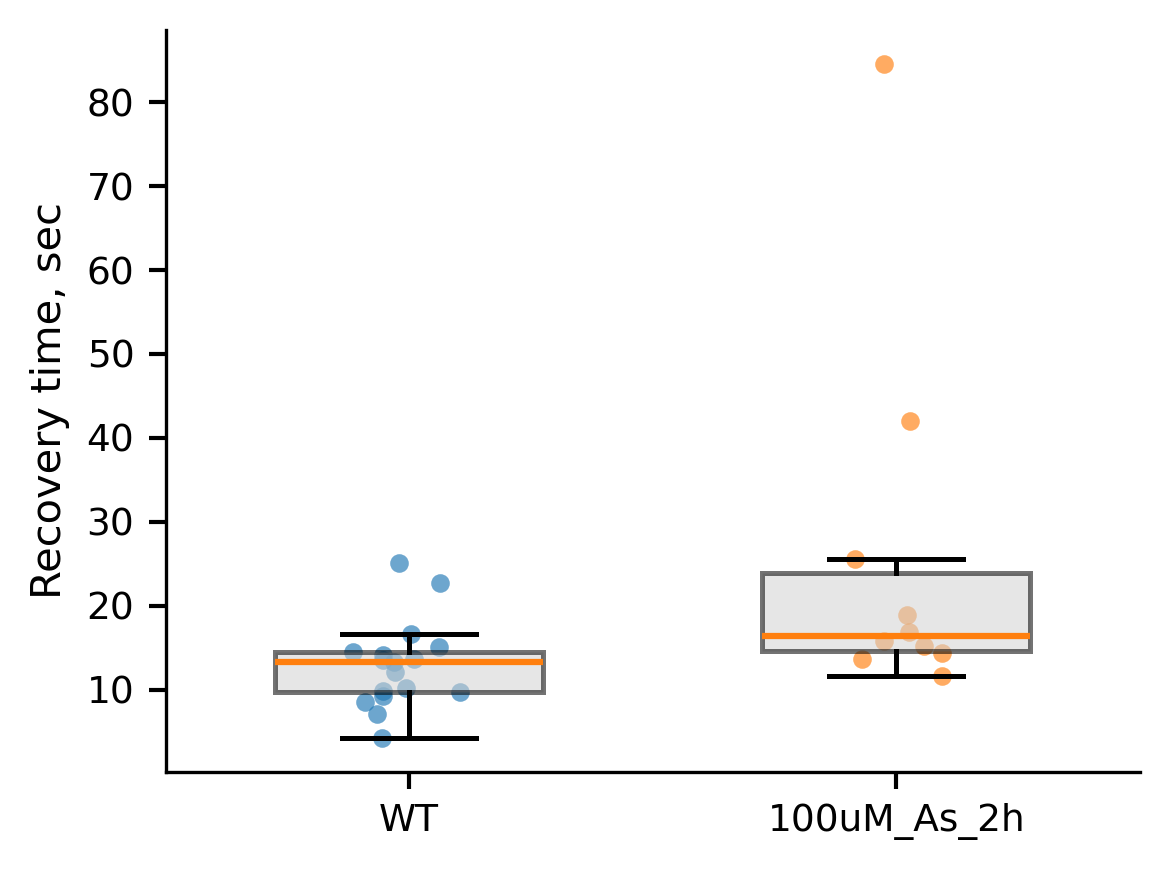

Plot Mobile Fraction for is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new.


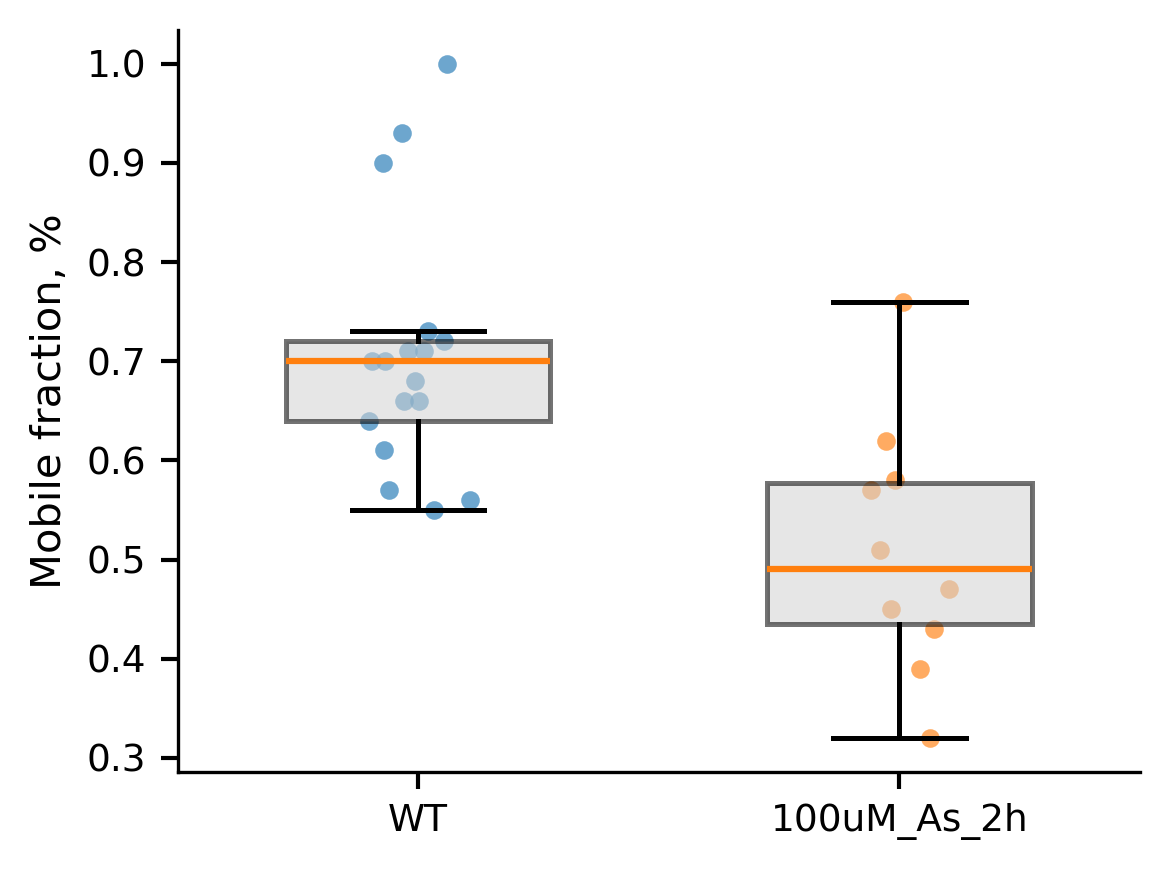

In [5]:
args = [{'var': "T-half", 'ylabel':'Recovery time, sec', 'title':''},
        {'var': "Mobile Fraction", 'ylabel':'Mobile fraction, %', 'title': ''},
]

for arg in args:
    beautiful_boxplot(
        df_list=[
                dfs[0][arg['var']],
                dfs[1][arg['var']]
                ],
        labels=sample_names,
        ylabel=arg['ylabel'],
        title=arg['title'],
        show = True,
        save = True,
        name = arg['var'],
        output_dir = graphs_folder
    )

## Mann-Whitney statistical analysis

### Mobile fraction, %

In [7]:
mannwhitneyu_stats(data = dfs,
                  column_name = 'Mobile Fraction',
                  reference_index = 0,
                  save = True,
                  output_folder = graphs_folder)

The results are saved into the folder: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new


,comparison,stat,p_value,significant
0,WT vs MGS1,146.5,0.002179,True


### Half-time of recovery, sec

In [8]:
mannwhitneyu_stats(data = dfs,
                  column_name = 'T-half',
                  reference_index = 0,
                  save = True,
                  output_folder = graphs_folder)

The results are saved into the folder: /mnt/c/users/elopatukhin/Desktop/Data_processing/060326_U2OS_FRAP/final_graphs_new


,comparison,stat,p_value,significant
0,WT vs MGS1,31.0,0.007227,True
